# Workflow development

This is a little playground for me to develop functions that will be used in the final workflow.

## Imports

In [29]:
from rdkit import Chem, RDLogger
from rdkit.Chem import AllChem, Descriptors, rdMolDescriptors
from rdkit.Chem import Draw, PandasTools
from rdkit.Chem.EnumerateStereoisomers import EnumerateStereoisomers, StereoEnumerationOptions
import pandas as pd
import numpy as np
import MDAnalysis as mda
import nglview as nv
import os
import tempfile
from openmm.app import PDBFile
import requests
from pdbfixer import PDBFixer
from vina import Vina
import useful_rdkit_utils as uru
from molscrub import Scrub
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE" # needed to ensure Auto3D runs
import Auto3D
from Auto3D import Auto3DOptions, main
from rdkit.Chem.EnumerateStereoisomers import EnumerateStereoisomers, StereoEnumerationOptions
import tempfile
from pathlib import Path
from tqdm.auto import tqdm

tqdm.pandas()
RDLogger.DisableLog('rdApp.*') 

## Protein preparation

**NOTE TO SELF**: Should look into replacing `os.system` with `os.subprocess` - apparently that's safer and more professional.

In [ ]:
def _fix_protein(input_protein_path:str, output_directory_path:str):
    """Runs PDBFixer on the input protein structure to fix any issues such as missing residues, missing atoms, and nonstandard residues.
    The fixed structure is then saved to an internally specified output path (fixed_{input_protein_path}).

    Args:
        input_protein_path (str): The path to the input protein PDB file
        output_directory_path (str): The path to the directory where the fixed protein PDB file will be saved

    Returns:
        str: The path where the fixed protein PDB file has been saved.
    """
    # Initialise PDBFixer with input protein structure
    fixer = PDBFixer(filename=input_protein_path)

    # Identify problems with the structure and fix them
    fixer.findMissingResidues()
    fixer.findMissingAtoms()
    fixer.findNonstandardResidues()
    fixer.removeHeterogens(keepWater=False) # remove anything that isn't protein, including water and ligand(s).

    # Fix identified problems
    fixer.addMissingAtoms()
    fixer.replaceNonstandardResidues()

    # Save the fixed structure to the following output path
    output_filename = "fixed_"+os.path.split(input_protein_path)[-1] # grabs current name of input file and prepends "fixed_"
    fixed_protein_output_path = os.path.join(output_directory_path, output_filename)
    with open(fixed_protein_output_path, 'w') as f:
        # Toplology, Positions, file stream, and keep chain ID's
        PDBFile.writeFile(fixer.topology, fixer.positions, f, keepIds=True)
    
    return fixed_protein_output_path

def _protonate_protein(input_protein_path:str, output_directory_path:str, pH=7.4):
    """Runs pdb2pqr on the input protein structure to add hydrogens and assign protonated states based on the specified pH.
    The protonated structure is then saved to an internally specified output path.

    Args:
        input_protein_path (str): The path to the input protein PDB file
        output_directory_path (str): The path to the directory where the protonated protein .pqr and .pdb files will be saved
        pH (float, optional): The pH at which to assign protonated states. Defaults to 7.4 (physiological pH).

    Returns:
        str: The path where the protonated protein .pqr file has been saved.
    """

    # Defining output path and creating protonated files. A protonated .pdb file is created primarily for future visualisation.
    output_filename = os.path.split(input_protein_path)[-1].split(".")[0]+"_protonated" # grabs current name of input file, removes file extension, and appends "_protonated"
    protonated_protein_output_path = os.path.join(output_directory_path, output_filename)
    os.system(f"pdb2pqr --pdb-output={protonated_protein_output_path}.pdb --pH={pH} {input_protein_path} {protonated_protein_output_path}.pqr --whitespace")

    return f"{protonated_protein_output_path}.pqr"

def _pdb_to_pdbqt(input_protein_pqr_path:str, output_directory_path:str):
    """Writes a .pdbqt file ready for Autodock Vina given a .pqr generated by pdb2pqr.

    Args:
        input_protein_pqr_path (str): The path to the input protein .pqr file (created by pdb2pqr).
        output_directory_path (str): The path to the directory where the .pdbqt file will be saved.
    
    Returns:
    str: The path where the protein .pdbqt file has been saved.
    """

    u = mda.Universe(input_protein_pqr_path)
    output_filename = os.path.split(input_protein_pqr_path)[-1].split(".")[0]+".pdbqt" # grabs current name of input file, removes file extension, and appends ".pdbqt"
    output_filename = output_filename.replace("_protonated", "").replace("fixed", "") # removes "_protonated" and "fixed_" from the filename to match the original protein name
    pdbqt_output_path = os.path.join(output_directory_path, output_filename)
    u.atoms.write(pdbqt_output_path)

    # Read in the just-written PDBQT file, replace text, and write back
    with open(pdbqt_output_path, 'r') as file:
        file_content = file.read()

    # Replace 'TITLE' and 'CRYST1' with 'REMARK'
    file_content = file_content.replace('TITLE', 'REMARK').replace('CRYST1', 'REMARK')

    # Write the modified content back to the file
    with open(pdbqt_output_path, 'w') as file:
        file.write(file_content)
    
    return pdbqt_output_path

# Final function which will prepare the protein structure files with one function call.
def prepare_protein(input_protein_path:str, output_directory_path:str, pH=7.4): # THIS FUNCTION AND FUNCTIONS WITHIN THEM REQUIRE INPUT
    """Convenience function which fixes a protein structure with PDBFixer if any issues are present, then protonates the protein with
    pdb2pqr (propka under the hood) at a given pH, and converts the protonated structure file (.pqr used in this case) to a .pdbqt file
    ready for docking with Autodock Vina.

    Args:
        input_protein_path (str): Input protein PDB filepath.
        output_directory_path (str): Output directory path for the .pdbqt file.
        pH (float, optional): The pH at which to assign protonated states. Defaults to 7.4 (physiological pH).

    Returns:
    str: The path where the prepared protein .pdbqt file has been saved.
    """

    fixed_protein_path = _fix_protein(input_protein_path, output_directory_path)
    protonated_protein_pqr_path = _protonate_protein(fixed_protein_path, output_directory_path, pH=pH)
    pdbqt_path = _pdb_to_pdbqt(protonated_protein_pqr_path, output_directory_path)

    return pdbqt_path


## Ligand preparation

In [ ]:
def _protonate_ligand(smiles:str, pH=7.4, pH_deviation=2) -> list[str]:
    """Protonate a ligand molecule given its SMILES string, using the molscrub Scrub class to assign protonation states and
    enumerate tautomers based on the specified pH and deviation range.

    Args:
        smiles (str): Ligand SMILES string.
        pH (float, optional): pH at which to protonate the ligand. Defaults to 7.4.
        pH_deviation (int, optional): Deviation from the specified pH to consider. Defaults to 2.

    Returns:
        list[str]: A list of protonated ligand SMILES strings, including tautomers.
    """

    scrub = Scrub(
    ph_low=pH - pH_deviation,
    ph_high=pH + pH_deviation,
    skip_gen3d=True # We can skip 3D generation here as we will generate 3D conformers later in the workflow after docking (using Auto3D)
    )

    mol = Chem.MolFromSmiles(smiles)
    scrubbed_mols = scrub(mol)
    protonated_smiles = [Chem.MolToSmiles(mol) for mol in scrubbed_mols]

    return protonated_smiles

# Taken and slightly edited from Auto3D stereochemistry documentation: https://auto3d.readthedocs.io/en/latest/example/stereochemistry.html
def _enumerate_stereoisomers(smiles:str, max_isomers=16, only_unassigned=True) -> list[str]:
    """Enumerate all stereoisomers of a molecule. By default, if stereochemistry is specified, it will not be enumerated
    (controlled by the only_unassigned parameter). This function treats both E/Z and R/S stereoisomerism.

    Args:
        smiles (str): Input SMILES (can have undefined stereochemistry).
        max_isomers (int, optional): Maximum number of isomers to generate. Defaults to 16.
        only_unassigned (bool, optional): If set (default), stereocenters which have specified stereochemistry will not be perturbed unless they are part of a relative stereo group. Defaults to True.

    Returns:
        list[str]: List of enumerated SMILES with stereochemical information.
    """

    mol = Chem.MolFromSmiles(smiles)
    
    # Configure enumeration options
    opts = StereoEnumerationOptions(
        tryEmbedding=True,  # Verify 3D embedding is possible
        unique=True,        # Remove duplicates
        maxIsomers=max_isomers,
        onlyUnassigned=only_unassigned
    )
    
    isomers = list(EnumerateStereoisomers(mol, options=opts))
    isomer_smiles = [Chem.MolToSmiles(iso, isomericSmiles=True, canonical=True) for iso in isomers]

    return isomer_smiles

def write_isomer_smi(smiles_list:list[str], smi_file_path:str):
    """Write .smi file needed for Auto3D 3D generation.

    Args:
        smiles_list (list[str]): List of smiles to be saved into a .smi file.
        smi_file_path (str): Filepath to write .smi to.

    Returns:
        str: Filepath .smi file was written to.
    """

    print("Writing .smi file for Auto3D")
    smiles_dict = dict(zip(smiles_list, smiles_list))

    with open(smi_file_path, "w") as f:
    # with tempfile.NamedTemporaryFile(mode='w', suffix='.smi', delete=False) as f: # NEED TO LOOK BACK AT THIS TO SEE IF A TEMPORARY FILE IS APPROPRIATE
        for name, smi in smiles_dict.items():
            f.write(f"{smi} {name}\n")
        stereo_file = f.name
    
    print(f"Wrote {len(smiles_dict)} stereoisomers to {stereo_file}")
    return stereo_file

def generate_3d_conformers_auto3d(stereo_file_path:str, gpu_usage=False):
    """_summary_

    Args:
        stereo_file_path (str): .smi filepath containing enumerated isomer smiles.
        gpu_usage (bool, optional): Use GPU for Auto3D 3D structure generation. Defaults to False.

    Returns:
        str: .sdf filepath for the output structures and energies.
    """

    print("Generating 3D isomer structures")
    config = Auto3DOptions(
        path=stereo_file_path,
        k=1,                # Top conformer per stereoisomer
        optimizing_engine="AIMNET",
        use_gpu=gpu_usage, # Set to False by default - can switch to True if GPU is available
        enumerate_isomer=False,  # Don't enumerate - we already have all isomers
    )
    
    stereo_output = main(config)
    print(f"Output: {stereo_output}")
    return stereo_output

# Taken and slightly edited from Auto3D stereochemistry documentation: https://auto3d.readthedocs.io/en/latest/example/stereochemistry.html
def compare_stereoisomer_energies(sdf_path:str):
    """
    Compare energies of stereoisomers.
    
    Enantiomers should have identical energies in vacuum.
    Diastereomers will have different energies.
    """
    mols = list(Chem.SDMolSupplier(sdf_path, removeHs=False))
    
    data = []
    for mol in mols:
        if mol is None:
            continue
            
        name = mol.GetProp("_Name")
        
        # Get energy
        if mol.HasProp("E_hartree"):
            e = float(mol.GetProp("E_hartree"))
        elif mol.HasProp("E_tot"):
            e = float(mol.GetProp("E_tot")) / 27.2114
        else:
            continue
        
        # Get stereochemistry
        centers = Chem.FindMolChiralCenters(mol)
        stereo = "/".join([tag for _, tag in centers])
        
        data.append({
            "Name": name,
            "Stereo": stereo,
            "E_hartree": e
        })
    
    df = pd.DataFrame(data)
    df["E_kcal"] = (df["E_hartree"] - df["E_hartree"].min()) * 627.509
    
    return df#.sort_values("E_kcal")

def generate_3d_conformers():
    # An attempt at generating 3D conformers of a molecule for docking without relying on auto3d.
    ...


def prepare_ligands(smiles_list:list[str], pH=7.4, pH_deviation=2):

    
    # For below: progress_apply is from tqdm.pandas() and applies a function whilst showing a progress bar
    ligand_df = pd.DataFrame({"annalog": smiles_list})

    print("Protonating molecules...")
    ligand_df["protonated"] = ligand_df["annalog"].progress_apply(_protonate_ligand, pH=pH, pH_deviation=pH_deviation)
    ligand_df = ligand_df.explode("protonated", ignore_index=True)

    print("Enumerating isomers...")
    ligand_df["isomers"] = ligand_df["protonated"].progress_apply(_enumerate_stereoisomers)
    ligand_df = ligand_df.explode("isomers", ignore_index=True)
    

    return ligand_df

['C/C(F)=C(/F)C[C@](F)(Cl)Br', 'C/C(F)=C(/F)C[C@@](F)(Cl)Br', 'C/C(F)=C(\\F)C[C@](F)(Cl)Br', 'C/C(F)=C(\\F)C[C@@](F)(Cl)Br']


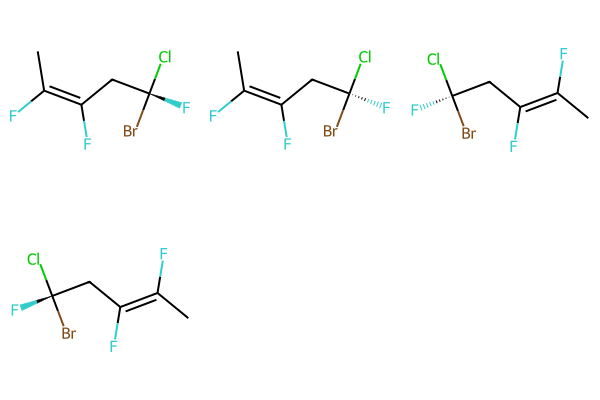

In [ ]:
stereo_enum_smiles = _enumerate_stereoisomers("CC(F)=C(F)CC(F)(Cl)Br")
print(stereo_enum_smiles)
Draw.MolsToGridImage([Chem.MolFromSmiles(s) for s in stereo_enum_smiles])

['C/C(F)=C\\F']


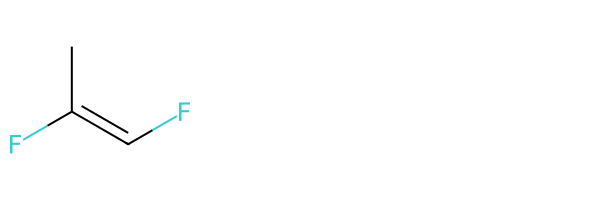

In [ ]:
stereo_enum_smiles = _enumerate_stereoisomers('C/C(F)=C\\F')
print(stereo_enum_smiles)
Draw.MolsToGridImage([Chem.MolFromSmiles(s) for s in stereo_enum_smiles])

['C/C(F)=C(/F)C[C@](F)(Cl)Br', 'C/C(F)=C(/F)C[C@@](F)(Cl)Br']


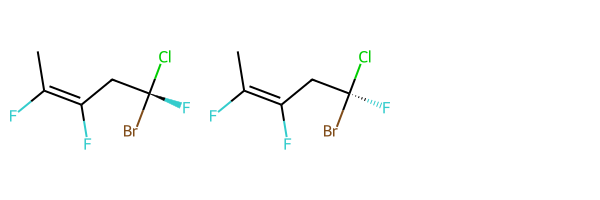

In [ ]:
stereo_enum_smiles = _enumerate_stereoisomers('C/C(F)=C(/F)CC(F)(Cl)Br')
print(stereo_enum_smiles)
Draw.MolsToGridImage([Chem.MolFromSmiles(s) for s in stereo_enum_smiles])

['O=C([O-])/C(F)=C(\\F)C[C@](F)(Cl)Br', 'O=C([O-])/C(F)=C(\\F)C[C@@](F)(Cl)Br', 'O=C([O-])/C(F)=C(/F)C[C@](F)(Cl)Br', 'O=C([O-])/C(F)=C(/F)C[C@@](F)(Cl)Br']


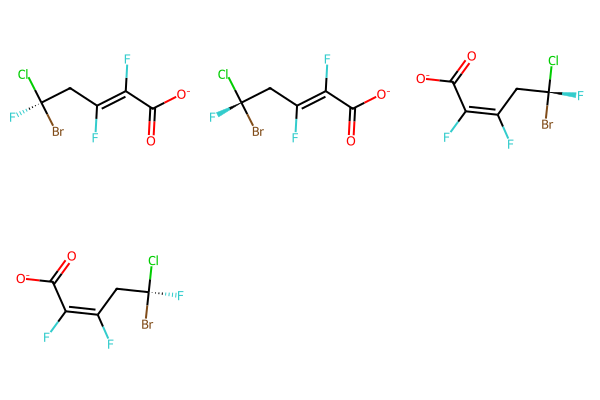

In [ ]:
stereo_enum_smiles = _enumerate_stereoisomers("[O-]C(=O)C(F)=C(F)CC(F)(Cl)Br")
print(stereo_enum_smiles)
Draw.MolsToGridImage([Chem.MolFromSmiles(s) for s in stereo_enum_smiles])

['[NH3+]/C(F)=C(\\F)C[C@](F)(Cl)Br', '[NH3+]/C(F)=C(\\F)C[C@@](F)(Cl)Br', '[NH3+]/C(F)=C(/F)C[C@](F)(Cl)Br', '[NH3+]/C(F)=C(/F)C[C@@](F)(Cl)Br']


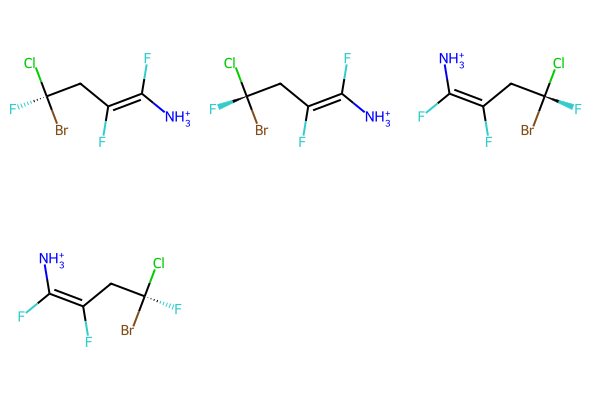

In [ ]:
stereo_enum_smiles = _enumerate_stereoisomers("[NH3+]C(F)=C(F)CC(F)(Cl)Br")
print(stereo_enum_smiles)
Draw.MolsToGridImage([Chem.MolFromSmiles(s) for s in stereo_enum_smiles])

In [ ]:
protonated_smiles = _protonate_ligand("Clc1c(OCCC3)c3ccc1C(=O)Nc2nc[nH]c2", pH=7.4, pH_deviation=2)

[11:57:22] Can't kekulize mol.  Unkekulized atoms: 0 1 3
[11:57:22] Can't kekulize mol.  Unkekulized atoms: 1 5 6
[11:57:22] Can't kekulize mol.  Unkekulized atoms: 4 6
[11:57:22] Can't kekulize mol.  Unkekulized atoms: 17 19
[11:57:22] Can't kekulize mol.  Unkekulized atoms: 1 5 6
[11:57:22] Can't kekulize mol.  Unkekulized atoms: 4 6
[11:57:22] Can't kekulize mol.  Unkekulized atoms: 17 19
[11:57:22] Can't kekulize mol.  Unkekulized atoms: 6 8
[11:57:22] Can't kekulize mol.  Unkekulized atoms: 1 4 5
[11:57:22] Can't kekulize mol.  Unkekulized atoms: 1 4 5
[11:57:22] Can't kekulize mol.  Unkekulized atoms: 4 5 6
[11:57:22] Can't kekulize mol.  Unkekulized atoms: 17 18 19
[11:57:22] Can't kekulize mol.  Unkekulized atoms: 1 5 6
[11:57:22] Can't kekulize mol.  Unkekulized atoms: 4 6
[11:57:22] Can't kekulize mol.  Unkekulized atoms: 17 19
[11:57:22] Can't kekulize mol.  Unkekulized atoms: 1 5 6
[11:57:22] Can't kekulize mol.  Unkekulized atoms: 1 5
[11:57:22] Can't kekulize mol.  Unkeku

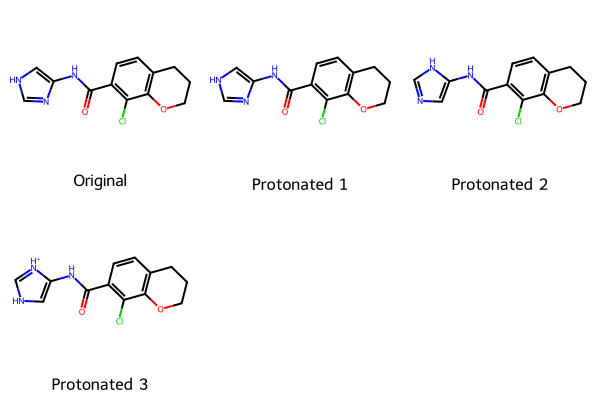

In [ ]:
Draw.MolsToGridImage([Chem.MolFromSmiles("Clc1c(OCCC3)c3ccc1C(=O)Nc2nc[nH]c2")]+[Chem.MolFromSmiles(smiles) for smiles in protonated_smiles],
                     legends=["Original"] + [f"Protonated {i+1}" for i in range(len(protonated_smiles))])

## ANNalog generation setup

In [41]:
! annalog-generate -i "C(C)Cc1c(C(=O)N)c(-c2ccc(C(NCc3occc3)=O)cc2)c(C(OCC)=O)c(CCc2ccc(F)cc2)n1" -n 5 -m beam

input_smiles	rank	generated_smiles	score	check_scaffold	check_skeleton	check_ring_systems	check_structural_alerts	check_lacan
[INFO] input SMILES unchanged after RDKit normalization : C(C)Cc1c(C(=O)N)c(-c2ccc(C(NCc3occc3)=O)cc2)c(C(OCC)=O)c(CCc2ccc(F)cc2)n1
C(C)Cc1c(C(=O)N)c(-c2ccc(C(NCc3occc3)=O)cc2)c(C(OCC)=O)c(CCc2ccc(F)cc2)n1	1	C(C)Cc1c(C(=O)N)c(-c2ccc(C(NCc3occc3)=O)cc2)c(C(OCC)=O)c(CCc2ccccc2)n1	-4.450586452591153	False	False	True	1	1.0
C(C)Cc1c(C(=O)N)c(-c2ccc(C(NCc3occc3)=O)cc2)c(C(OCC)=O)c(CCc2ccc(F)cc2)n1	2	C(C)Cc1c(C(=O)N)c(-c2ccc(C(NCc3ccccc3)=O)cc2)c(C(OCC)=O)c(CCc2ccccc2)n1	-4.499669931311757	False	True	True	1	1.0
C(C)Cc1c(C(=O)N)c(-c2ccc(C(NCc3occc3)=O)cc2)c(C(OCC)=O)c(CCc2ccc(F)cc2)n1	3	C(C)Cc1c(C(=O)N)c(-c2ccc(C(NCC3CC3)=O)cc2)c(C(OCC)=O)c(CCc2ccc(F)cc2)n1	-5.047486294209705	False	False	True	1	1.0
C(C)Cc1c(C(=O)N)c(-c2ccc(C(NCc3occc3)=O)cc2)c(C(OCC)=O)c(CCc2ccc(F)cc2)n1	4	C(C)Cc1c(C(=O)N)c(-c2ccc(C(N)=O)cc2)c(C(OCC)=O)c(CCc2ccc(F)cc2)n1	-5.168722437152439	False	True	Tr

In [53]:
def annalog_generate(n_mol_to_gen:int, input_path_or_smiles:str, output_file:str, method="beam", number_of_variants=5):
    """Generate SMILES with ANNalog. Variants are used to generate multiple variant SMILES per input SMILES.
    The total number of molecules to generate is passed in, and internally this is converted into a number of molecules
    to generate per input SMILES, additionally given the number of variants to generate per input SMILES.

    Args:
        n_mol_to_gen (int): Number of molecules to generate in total.
        input_path_or_smiles (str): Path to input file or SMILES string
        output_file (str): Path to output file, as a .tsv or .csv file.
        method (str, optional): Generation method. Defaults to "beam". Other options are: "BF-beam" and "sampling".
        number_of_variants (int, optional): Number of variants to generate. Defaults to 5.
    """
    # computing the number of molecules to generate per input SMILES, given the total number of molecules to generate.
    n_mol_to_gen_per_input = n_mol_to_gen // number_of_variants # integer division to ensure we get an integer number of molecules to generate per input SMILES.
    os.system(f"annalog-generate -i '{input_path_or_smiles}' -n {n_mol_to_gen_per_input} -m {method} -o {output_file} -e variants --variant-number {number_of_variants}")

def load_generated_molecules(generated_molecules_path:str):
    """Convenience function to load generated molecules from a .tsv file and add RDKit molecule columns for both input and generated SMILES.

    Args:
        generated_molecules_path (str): Path to the .tsv file containing generated molecules.

    Returns:
        pd.DataFrame: DataFrame containing the generated molecules with RDKit molecule columns.
    """

    df = pd.read_csv(generated_molecules_path, sep="\t")
    return df

def deduplicate_generated_molecules(generated_df:pd.DataFrame):
    generated_df["canonical_input_smiles"] = generated_df["input_smiles"].apply(Chem.CanonSmiles)
    generated_df["canonical_generated_smiles"] = generated_df["generated_smiles"].apply(Chem.CanonSmiles)
    generated_df = generated_df.drop_duplicates("canonical_generated_smiles") # remove duplicate generated molecules
    generated_df = generated_df[generated_df["canonical_input_smiles"] != generated_df["canonical_generated_smiles"]] # remove generated molecules that are the same as its input molecule
    generated_df = generated_df.reset_index(drop=True)
    return generated_df


## Quick generation and ligand prep test

In [94]:
ligand_5ZTY = "Cc1c(n(nc1C(=O)NC23CC4CC(C2)CC(C4)C3)CCCCCO)c5ccccc5"
annalog_generate(20, ligand_5ZTY, "test.tsv")

[INFO] input SMILES changed after RDKit normalization, using RDKit processed version : Cc1c(-c2ccccc2)n(CCCCCO)nc1C(=O)NC12CC3CC(C1)CC(C3)C2 as input


In [95]:
generated_df = load_generated_molecules("test.tsv")
generated_df = deduplicate_generated_molecules(generated_df)
generated_df

,input_smiles,rank,generated_smiles,score,check_scaffold,check_skeleton,check_ring_systems,check_structural_alerts,check_lacan,canonical_input_smiles,canonical_generated_smiles
0,Cc1c(n(nc1C(=O)NC23CC4CC(C2)CC(C4)C3)CCCCCO)c5...,1,O=C(NC12CC3CC(CC(C3)C1)C2)c1c(C)c(-c2ccccc2)n(...,-4.794945,True,True,True,1,0.0,Cc1c(C(=O)NC23CC4CC(CC(C4)C2)C3)nn(CCCCCO)c1-c...,Cc1c(C(=O)NC23CC4CC(CC(C4)C2)C3)nn(C)c1-c1ccccc1
1,Cc1c(n(nc1C(=O)NC23CC4CC(C2)CC(C4)C3)CCCCCO)c5...,2,O=C(NC12CC3CC(CC(C3)C1)C2)c1c(C)c(-c2ccccc2)n(...,-5.540682,False,True,True,1,0.0,Cc1c(C(=O)NC23CC4CC(CC(C4)C2)C3)nn(CCCCCO)c1-c...,Cc1c(C(=O)NC23CC4CC(CC(C4)C2)C3)nn(C2CCCCC2)c1...
2,Cc1c(n(nc1C(=O)NC23CC4CC(C2)CC(C4)C3)CCCCCO)c5...,3,O=C(NC12CC3CC(CC(C3)C1)C2)c1c(C)c(-c2ccccc2)n(...,-5.589937,True,True,True,1,0.0,Cc1c(C(=O)NC23CC4CC(CC(C4)C2)C3)nn(CCCCCO)c1-c...,Cc1c(C(=O)NC23CC4CC(CC(C4)C2)C3)nn(CCCO)c1-c1c...
3,Cc1c(n(nc1C(=O)NC23CC4CC(C2)CC(C4)C3)CCCCCO)c5...,4,O=C(NC12CC3CC(CC(C3)C1)C2)c1c(C)c(-c2ccc(OC)cc...,-5.739724,True,True,True,1,0.0,Cc1c(C(=O)NC23CC4CC(CC(C4)C2)C3)nn(CCCCCO)c1-c...,COc1ccc(-c2c(C)c(C(=O)NC34CC5CC(CC(C5)C3)C4)nn...
4,Cc1c(n(nc1C(=O)NC23CC4CC(C2)CC(C4)C3)CCCCCO)c5...,6,c1(-c2ccccc2)n(-c2ccccc2)nc(C(Nc2ccccc2)=O)c1C,-6.087401,True,True,True,0,1.0,Cc1c(C(=O)NC23CC4CC(CC(C4)C2)C3)nn(CCCCCO)c1-c...,Cc1c(C(=O)Nc2ccccc2)nn(-c2ccccc2)c1-c1ccccc1
5,Cc1c(n(nc1C(=O)NC23CC4CC(C2)CC(C4)C3)CCCCCO)c5...,7,c1(-c2ccccc2)n(C)nc(C(NC23CC4CC(CC(C4)C2)C3)=O)c1,-6.129431,True,True,True,1,0.0,Cc1c(C(=O)NC23CC4CC(CC(C4)C2)C3)nn(CCCCCO)c1-c...,Cn1nc(C(=O)NC23CC4CC(CC(C4)C2)C3)cc1-c1ccccc1
6,Cc1c(n(nc1C(=O)NC23CC4CC(C2)CC(C4)C3)CCCCCO)c5...,8,c1(-c2ccccc2)n(C)nc(C(NC23CC4CC(CC(C4)C2)C3)=O...,-6.510480,True,True,True,1,0.0,Cc1c(C(=O)NC23CC4CC(CC(C4)C2)C3)nn(CCCCCO)c1-c...,CCc1c(C(=O)NC23CC4CC(CC(C4)C2)C3)nn(C)c1-c1ccccc1
7,Cc1c(n(nc1C(=O)NC23CC4CC(C2)CC(C4)C3)CCCCCO)c5...,11,C1C2CC3(NC(=O)c4c(C)c(-c5ccccc5)n(CCO)n4)CC(CC...,-3.917982,True,True,True,1,0.0,Cc1c(C(=O)NC23CC4CC(CC(C4)C2)C3)nn(CCCCCO)c1-c...,Cc1c(C(=O)NC23CC4CC(CC(C4)C2)C3)nn(CCO)c1-c1cc...
8,Cc1c(n(nc1C(=O)NC23CC4CC(C2)CC(C4)C3)CCCCCO)c5...,12,C1C2CC3(NC(=O)c4c(C)c(-c5ccccc5)n(CCOC)n4)CC(C...,-3.922552,True,True,True,1,0.0,Cc1c(C(=O)NC23CC4CC(CC(C4)C2)C3)nn(CCCCCO)c1-c...,COCCn1nc(C(=O)NC23CC4CC(CC(C4)C2)C3)c(C)c1-c1c...
9,Cc1c(n(nc1C(=O)NC23CC4CC(C2)CC(C4)C3)CCCCCO)c5...,13,OCCCCCn1nc(C(=O)NC2CCCCC2)c(C)c1-c1ccccc1,-4.577757,False,True,True,2,1.0,Cc1c(C(=O)NC23CC4CC(CC(C4)C2)C3)nn(CCCCCO)c1-c...,Cc1c(C(=O)NC2CCCCC2)nn(CCCCCO)c1-c1ccccc1


In [96]:
generated_molecules = generated_df.copy()["generated_smiles"]
prepared_ligand_df = prepare_ligands(generated_molecules)
prepared_ligand_df.to_csv(os.path.join("results", "prepared_ligands.csv"), index=False)
prepared_ligand_df

Protonating molecules...


  0%|          | 0/13 [00:00<?, ?it/s]

Enumerating isomers...


  0%|          | 0/13 [00:00<?, ?it/s]

,annalog,protonated,isomers
0,O=C(NC12CC3CC(CC(C3)C1)C2)c1c(C)c(-c2ccccc2)n(...,Cc1c(C(=O)NC23CC4CC(CC(C4)C2)C3)nn(C)c1-c1ccccc1,Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...
1,O=C(NC12CC3CC(CC(C3)C1)C2)c1c(C)c(-c2ccccc2)n(...,Cc1c(C(=O)NC23CC4CC(CC(C4)C2)C3)nn(C2CCCCC2)c1...,Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...
2,O=C(NC12CC3CC(CC(C3)C1)C2)c1c(C)c(-c2ccccc2)n(...,Cc1c(C(=O)NC23CC4CC(CC(C4)C2)C3)nn(CCCO)c1-c1c...,Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...
3,O=C(NC12CC3CC(CC(C3)C1)C2)c1c(C)c(-c2ccc(OC)cc...,COc1ccc(-c2c(C)c(C(=O)NC34CC5CC(CC(C5)C3)C4)nn...,COc1ccc(-c2c(C)c(C(=O)N[C@]34C[C@H]5C[C@H](C[C...
4,c1(-c2ccccc2)n(-c2ccccc2)nc(C(Nc2ccccc2)=O)c1C,Cc1c(C(=O)Nc2ccccc2)nn(-c2ccccc2)c1-c1ccccc1,Cc1c(C(=O)Nc2ccccc2)nn(-c2ccccc2)c1-c1ccccc1
5,c1(-c2ccccc2)n(C)nc(C(NC23CC4CC(CC(C4)C2)C3)=O)c1,Cn1nc(C(=O)NC23CC4CC(CC(C4)C2)C3)cc1-c1ccccc1,Cn1nc(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C...
6,c1(-c2ccccc2)n(C)nc(C(NC23CC4CC(CC(C4)C2)C3)=O...,CCc1c(C(=O)NC23CC4CC(CC(C4)C2)C3)nn(C)c1-c1ccccc1,CCc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C...
7,C1C2CC3(NC(=O)c4c(C)c(-c5ccccc5)n(CCO)n4)CC(CC...,Cc1c(C(=O)NC23CC4CC(CC(C4)C2)C3)nn(CCO)c1-c1cc...,Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...
8,C1C2CC3(NC(=O)c4c(C)c(-c5ccccc5)n(CCOC)n4)CC(C...,COCCn1nc(C(=O)NC23CC4CC(CC(C4)C2)C3)c(C)c1-c1c...,COCCn1nc(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C...
9,OCCCCCn1nc(C(=O)NC2CCCCC2)c(C)c1-c1ccccc1,Cc1c(C(=O)NC2CCCCC2)nn(CCCCCO)c1-c1ccccc1,Cc1c(C(=O)NC2CCCCC2)nn(CCCCCO)c1-c1ccccc1


In [97]:
prepared_ligand_df = pd.read_csv(os.path.join("results", "prepared_ligands.csv"))
prepared_ligand_df


,annalog,protonated,isomers
0,O=C(NC12CC3CC(CC(C3)C1)C2)c1c(C)c(-c2ccccc2)n(...,Cc1c(C(=O)NC23CC4CC(CC(C4)C2)C3)nn(C)c1-c1ccccc1,Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...
1,O=C(NC12CC3CC(CC(C3)C1)C2)c1c(C)c(-c2ccccc2)n(...,Cc1c(C(=O)NC23CC4CC(CC(C4)C2)C3)nn(C2CCCCC2)c1...,Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...
2,O=C(NC12CC3CC(CC(C3)C1)C2)c1c(C)c(-c2ccccc2)n(...,Cc1c(C(=O)NC23CC4CC(CC(C4)C2)C3)nn(CCCO)c1-c1c...,Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...
3,O=C(NC12CC3CC(CC(C3)C1)C2)c1c(C)c(-c2ccc(OC)cc...,COc1ccc(-c2c(C)c(C(=O)NC34CC5CC(CC(C5)C3)C4)nn...,COc1ccc(-c2c(C)c(C(=O)N[C@]34C[C@H]5C[C@H](C[C...
4,c1(-c2ccccc2)n(-c2ccccc2)nc(C(Nc2ccccc2)=O)c1C,Cc1c(C(=O)Nc2ccccc2)nn(-c2ccccc2)c1-c1ccccc1,Cc1c(C(=O)Nc2ccccc2)nn(-c2ccccc2)c1-c1ccccc1
5,c1(-c2ccccc2)n(C)nc(C(NC23CC4CC(CC(C4)C2)C3)=O)c1,Cn1nc(C(=O)NC23CC4CC(CC(C4)C2)C3)cc1-c1ccccc1,Cn1nc(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C...
6,c1(-c2ccccc2)n(C)nc(C(NC23CC4CC(CC(C4)C2)C3)=O...,CCc1c(C(=O)NC23CC4CC(CC(C4)C2)C3)nn(C)c1-c1ccccc1,CCc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C...
7,C1C2CC3(NC(=O)c4c(C)c(-c5ccccc5)n(CCO)n4)CC(CC...,Cc1c(C(=O)NC23CC4CC(CC(C4)C2)C3)nn(CCO)c1-c1cc...,Cc1c(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C2)C3...
8,C1C2CC3(NC(=O)c4c(C)c(-c5ccccc5)n(CCOC)n4)CC(C...,COCCn1nc(C(=O)NC23CC4CC(CC(C4)C2)C3)c(C)c1-c1c...,COCCn1nc(C(=O)N[C@]23C[C@H]4C[C@H](C[C@H](C4)C...
9,OCCCCCn1nc(C(=O)NC2CCCCC2)c(C)c1-c1ccccc1,Cc1c(C(=O)NC2CCCCC2)nn(CCCCCO)c1-c1ccccc1,Cc1c(C(=O)NC2CCCCC2)nn(CCCCCO)c1-c1ccccc1


In [105]:
isomer_smi_filepath = os.path.join("results", "prepared_ligands.smi")
write_isomer_smi(prepared_ligand_df["isomers"], isomer_smi_filepath)
generate_3d_conformers_auto3d(isomer_smi_filepath)

Checking input file...
	There are 13 SMILES in the input file results/prepared_ligands.smi.
	All SMILES and IDs are valid.
Suggestions for choosing isomer_engine and optimizing_engine: 
	Isomer engine options: RDKit and Omega.
	Optimizing engine options: AIMNET (or an aimnet registry name like aimnet2-2025), ANI2x, ANI2xt, or your own NNP.


Writing .smi file for Auto3D
Wrote 13 stereoisomers to results/prepared_ligands.smi
Generating 3D isomer structures


The available memory is 16 GB.
The task will be divided into 1 jobs.
Job1, number of inputs: 13
100%|██████████| 13/13 [00:26<00:00,  2.01s/it]
INFO:Auto3D.batch_opt.batchopt:Preparing for parallel optimizing... (Max optimization steps: 2000)
INFO:Auto3D.batch_opt.batchopt:Total 3D conformers: 1489 in 2 size-bucket(s)
  0%|          | 0/2000 [00:00<?, ?it/s]Process Process-7:
Traceback (most recent call last):
  File "/Users/dcriveanu/Documents/AI_for_Drug_Discovery_MSc/Research_Project/project_working_area/workflow_development/.pixi/envs/default/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/Users/dcriveanu/Documents/AI_for_Drug_Discovery_MSc/Research_Project/project_working_area/workflow_development/.pixi/envs/default/lib/python3.12/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/Users/dcriveanu/Documents/AI_for_Drug_Discovery_MSc/Research_Project/project_working_area/workflow_developmen

KeyboardInterrupt: 

## Docking setup

In [ ]:
def _get_receptor_grid(protein_with_ligand_struct_path:str, buffer=5):
    """Calculate a docking receptor grid's box centre and box dimensions based on a protein-ligand co-crystal.
    The box centre is calculated as the centroid of the bound ligand, and the box dimensions are calculated as
    the maximum extent of the ligand in each dimension, plus a buffer to ensure the ligand fits comfortably within
    the box.

    Args:
        protein_with_ligand_struct_path (str): Filepath to a protein-ligand co-crystal structure (PDB format).
        buffer (int, optional): Buffer size in Angstroms to add to the box dimensions. Defaults to 5.

    Returns:
        tuple[list]: A tuple containing the box centre and box dimensions.
    """
    u = mda.Universe(protein_with_ligand_struct_path)
    ligand = u.select_atoms("not protein")
    box_centre = ligand.center_of_geometry()
    box_dimensions = np.ceil(ligand.positions.max(axis=0) - ligand.positions.min(axis=0)) + buffer # np.ceil is used to round up the dimensions to the larger nearest integer for ease of reporting size.

    return box_centre, box_dimensions

def vina_setup_receptor(vina_object:Vina, protein_with_ligand_struct_path:str, protein_pdbqt_path:str):
    """Initialise and setup a Vina object with a receptor structure and receptor grid.

    Args:
        vina_object (Vina): An instance of the Vina class from the vina package.
        protein_with_ligand_struct_path (str): Filepath to a protein-ligand co-crystal structure (PDB format).
        protein_pdbqt_path (str): Filepath to the prepared protein .pdbqt file.

    Returns:
        Vina: The initialised Vina object with the receptor structure and receptor grid set up.
    """
    box_centre, box_dimensions = _get_receptor_grid(protein_with_ligand_struct_path)
    vina_object.set_receptor(protein_pdbqt_path)
    vina_object.compute_vina_maps(center=box_centre, box_size=box_dimensions)
    return vina_object

def vina_dock_ligand(vina_object:Vina, ligand_pdbqt:str, n_poses, exhaustiveness):
    """Dock a ligand to a receptor using a Vina object.

    Args:
        vina_object (Vina): An instance of the Vina class from the vina package, with the receptor structure and grid set up.
        ligand_pdbqt (str): Filepath to the prepared ligand .pdbqt file.
        n_poses (int): Number of docking poses to generate.
        exhaustiveness (int): Exhaustiveness of the global search. Higher values lead to more thorough searches but take longer.

    Returns:
        list[tuple]: A list of tuples containing the docking poses and their corresponding scores.
    """
    vina_object.set_ligand_from_file(ligand_pdbqt)
    vina_object.dock(exhaustiveness=exhaustiveness, n_poses=n_poses)
    return vina_object

def get_best_docking_energy(vina_object:Vina):
    return vina_object.energies()[0,0] # this grabs the total energy of the best (lowest energy) pose

def write_docking_pose(vina_object:Vina, output_path:str):
    vina_object.write_poses(output_path, n_poses=9, overwrite=True)

In [ ]:
# input and output directories for the workflow
workflow_results_dir = os.path.join("results", "workflow") # working directory for the workflow results, which will contain subdirectories for each round of generation and docking.
input_protein_structure_path = os.path.join("Structures", "refined_cnr2_human_5ZTY_inactive.pdb") # protein structure to dock to (refined version of PDB ID: 5ZTY from GPCRdb - CB2 receptor)
output_protein_structures_path = os.path.join(workflow_results_dir, "protein") # output directory path for the prepared protein files

# workflow settings
## preparation settings (protein+ligand)
initial_ligand_smiles = "Cc1c(nn(CCCCCO)c1c2ccccc2)C(=O)NC34CC5CC(CC(C5)C3)C4" # PDB ligand ID: 9JU, bound to PDB ID 5ZTY
pH = 7.4 # physiological pH - specified for ligand and protein protonation

## docking settings
exhaustiveness = 16 # doubled from the default of 8
n_pose = 20

# protein preparation

prepare_protein(input_protein_structure_path, output_protein_structures_path, pH=pH)


v=Vina(sf_name="vina") # using the default vina scoring function



protein_pdbqt_path = os.path.join("redocking", "5ZTY_inactive", "structures", "protein", "5ZTY_inactive.pdbqt")
ideal_ligand_pdbqt_filepath = os.path.join("redocking", "5ZTY_inactive", "structures", "ligand", "9JU_ideal.pdbqt")
box_centre = [  9.09345159,  -0.16790321, -55.72312878]
box_dimensions = [13., 16., 15.]

v.set_receptor(protein_pdbqt_path)
v.set_ligand_from_file(ideal_ligand_pdbqt_filepath)
v.compute_vina_maps(center=box_centre, box_size=box_dimensions)

In [ ]:

round_no = 0 # this is a counter that will be added to as generation and docking rounds are completed

generation_dir = os.path.join(workflow_results_dir, "generation", f"round_{round_no}")
os.makedirs(generation_dir)

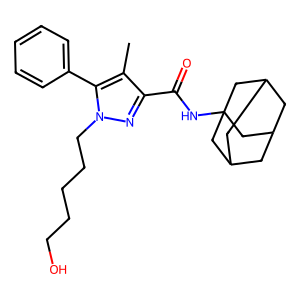

In [3]:
ligand_5ZTY = "Cc1c(n(nc1C(=O)NC23CC4CC(C2)CC(C4)C3)CCCCCO)c5ccccc5"
Draw.MolToImage(Chem.MolFromSmiles(ligand_5ZTY))

In [7]:
annalog_generate(n_mol_to_gen=5, input_path_or_smiles=ligand_5ZTY, output_file="test.tsv", method="beam", number_of_variants=5)

[INFO] input SMILES changed after RDKit normalization, using RDKit processed version : Cc1c(-c2ccccc2)n(CCCCCO)nc1C(=O)NC12CC3CC(C1)CC(C3)C2 as input


,input_smiles,rank,generated_smiles,score,check_scaffold,check_skeleton,check_ring_systems,check_structural_alerts,check_lacan,input_mol,generated_mol
0,Cc1c(n(nc1C(=O)NC23CC4CC(C2)CC(C4)C3)CCCCCO)c5...,1,c1c(-c2n(CCO)nc(C(=O)NC34CC5CC(CC(C3)C5)C4)c2C...,-4.798061,True,True,True,1,0.0,,
1,Cc1c(n(nc1C(=O)NC23CC4CC(C2)CC(C4)C3)CCCCCO)c5...,2,c1c(-c2n(C)nc(C(=O)NC34CC5CC(CC(C3)C5)C4)c2C)c...,-4.824264,True,True,True,1,0.0,,
2,Cc1c(n(nc1C(=O)NC23CC4CC(C2)CC(C4)C3)CCCCCO)c5...,3,c1c(-c2n(CCCO)nc(C(=O)NC34CC5CC(CC(C3)C5)C4)c2...,-5.008858,True,True,True,1,0.0,,
3,Cc1c(n(nc1C(=O)NC23CC4CC(C2)CC(C4)C3)CCCCCO)c5...,4,c1c(-c2n(CCCCCO)nc(C(=O)NC3CCCCC3)c2C)cccc1,-5.306885,False,True,True,2,1.0,,
4,Cc1c(n(nc1C(=O)NC23CC4CC(C2)CC(C4)C3)CCCCCO)c5...,5,c1c(-c2n(CCCCO)nc(C(=O)NC34CC5CC(CC(C3)C5)C4)c...,-5.350474,True,True,True,2,0.0,,
5,Cc1c(n(nc1C(=O)NC23CC4CC(C2)CC(C4)C3)CCCCCO)c5...,6,c1(C)c(-c2ccccc2)n(C)nc1C(NC12CC3CC(CC(C1)C3)C...,-4.060705,True,True,True,1,0.0,,
6,Cc1c(n(nc1C(=O)NC23CC4CC(C2)CC(C4)C3)CCCCCO)c5...,7,c1(C)c(-c2ccccc2)n(-c2ccccc2)nc1C(NC1CCCCC1)=O,-5.152297,True,True,True,0,1.0,,
7,Cc1c(n(nc1C(=O)NC23CC4CC(C2)CC(C4)C3)CCCCCO)c5...,8,c1(C)c(-c2ccccc2)n(-c2ccccc2)nc1C(Nc1ccc(Cl)cc...,-5.473428,True,True,True,0,1.0,,
8,Cc1c(n(nc1C(=O)NC23CC4CC(C2)CC(C4)C3)CCCCCO)c5...,9,c1(C)c(-c2ccccc2)n(-c2ccccc2)nc1C(Nc1ccccc1)=O,-6.220309,True,True,True,0,1.0,,
9,Cc1c(n(nc1C(=O)NC23CC4CC(C2)CC(C4)C3)CCCCCO)c5...,10,c1(C)c(-c2ccccc2)n(C)nc1C(NC12CC3CC(CC(C1)C3)C...,-6.237667,False,True,True,3,0.0,,

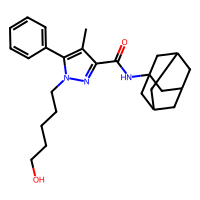
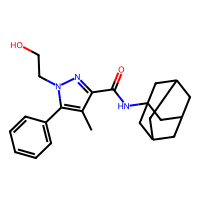
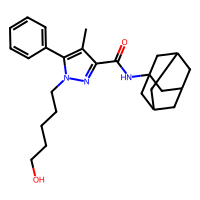
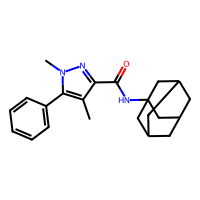
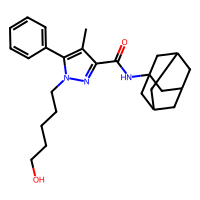
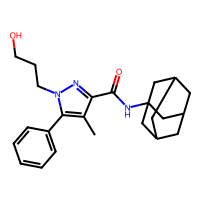
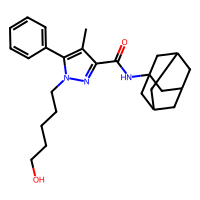
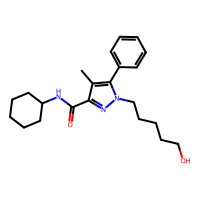
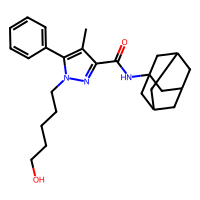
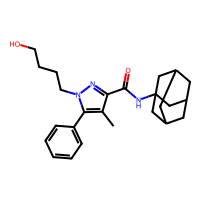
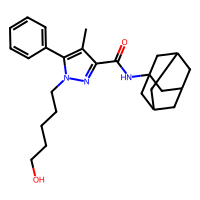
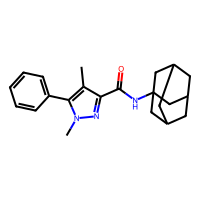
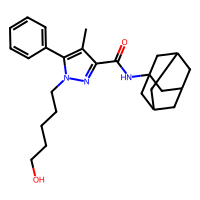
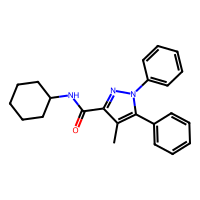
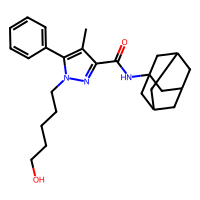
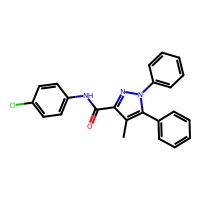
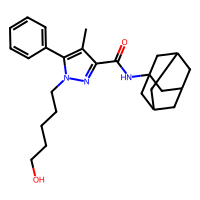
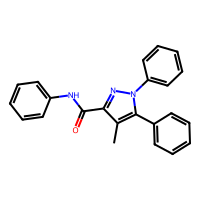
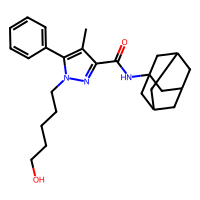
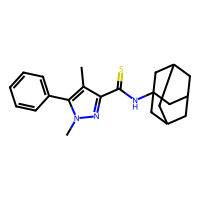
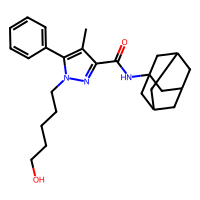
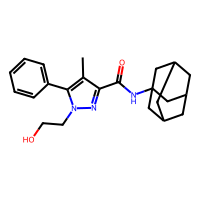
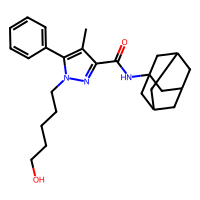
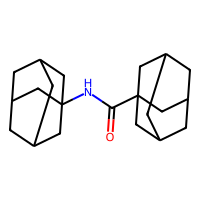
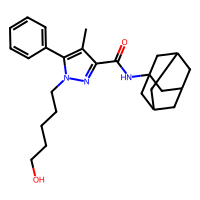
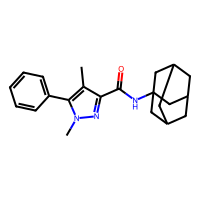
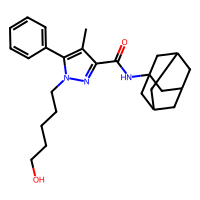
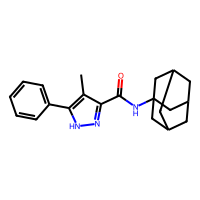
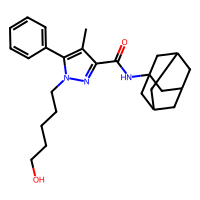
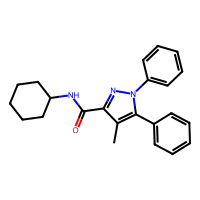
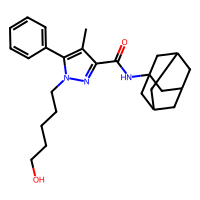
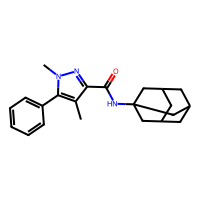
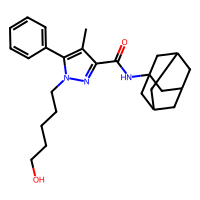
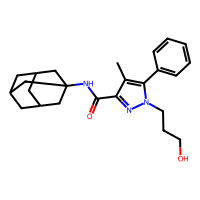
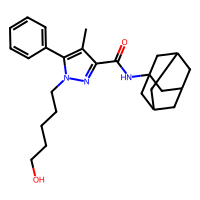
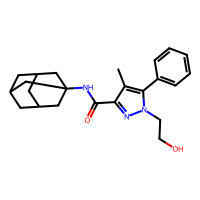
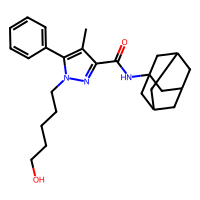
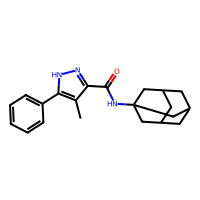
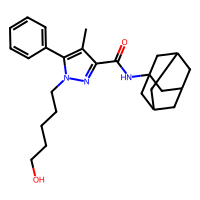
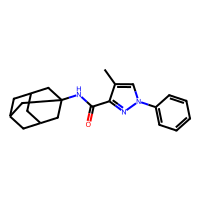
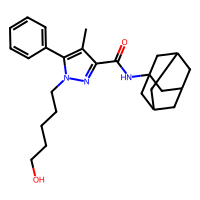
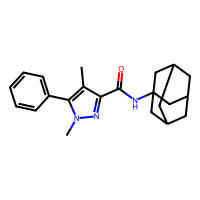
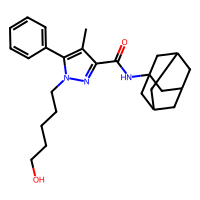
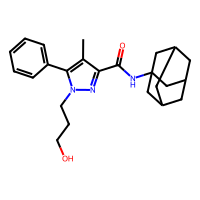
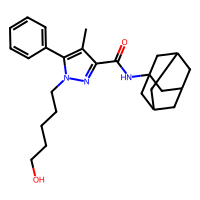
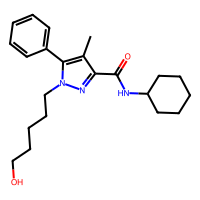
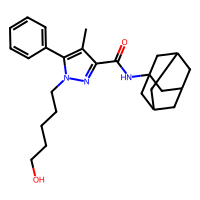
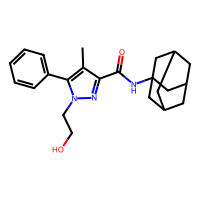
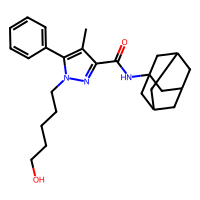
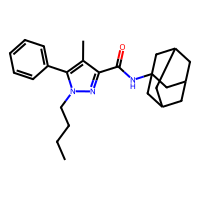

In [15]:
load_generated_molecules("test.tsv")